# Trabalho 2

In [2]:
from pose import Pose
from angle import Angle
from control import VelocityControl
from robot import Robot
from distributions import GaussianDistribution
from maps import LandmarkMap, Landmark
from sensor import Camera, DetectedFeature

import matplotlib.pyplot as plt
import numpy as np

/home/jtu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Landmark Based Localization

### Map of Landmarks
A map of landmarks is basically a list, where each entry is associated with a set of coordinates for the landmark's position and a signature. A landmark $\mathcal{L}$, i.e. one entry in the map's list, is then defined as follows

$$\mathcal{L} = (x, y, s)$$

where $s$ denotes the landmarks unique signature.

>**Note:** the angle is not used in this implementation to simplify the algorithms and representations.

>**Note:** the singnature is equal to its index in the list of landmarks in this example of map, as this simplifies the algorithms in matching detected features with landmarks of the map. In reality the matching may include computer vision or other more complex and computationally intense algorithms

In [3]:
x_lims = [-5., 5.] 
y_lims = [-5., 5.]

m = LandmarkMap([
        Landmark(Pose(0, 0, Angle(0)), 0),
        Landmark(Pose(-3, 0, Angle(0)), 1),
        Landmark(Pose(0, -3, Angle(0)), 2),
    ],
    x_lims = x_lims,
    y_lims = y_lims 
)

# initial position of the robot
x0 = Pose(-3, -3, Angle.from_deg(55))

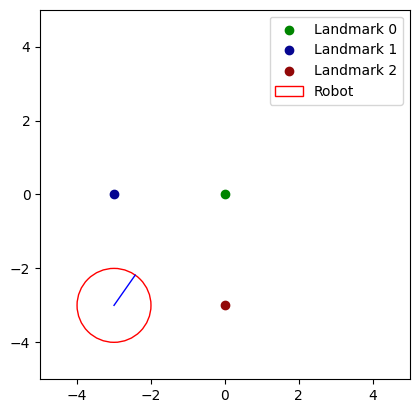

In [4]:
f = plt.figure()
ax = f.gca()

m.draw(ax, landmark_labels = True)
Robot(x0).draw(ax)

### Landmark Localizaition Probability Distribution
This algorithm computes the likelyhood of a given measurement for a pose in the space given a map of landmarks. This is done via the error between the actual measurement and the expected measurement at given location.


> **Note:** the `landmark_model_known_correspondence` has been adapted to take into consideration the orientation of the hypothesis $\theta_h$ by computing $$\hat{\phi} = \text{atan2}(dy, dx) - \theta_h$$ instead of simply computing $$\hat{\phi} = \text{atan2}(dy, dx)$$. If the subrtaction of $\theta_h$ is ommited, it is implicitly assumed that the hypothesis has a zero orientation, and the results will only be meaningfull if the robot took the measurement with zero orientation.

In [5]:
def landmark_model_known_correspondence(feature: DetectedFeature, correspondence: int, x_hypothesis: Pose, map: LandmarkMap, sigmas = [0.1, 0.1, 0.1]):
    [sigma_r, sigma_phi, sigma_s] = sigmas

    l = map.landmarks[correspondence]
    m_x, m_y, m_s = l.pos.x, l.pos.y, l.signture

    dx = m_x - x_hypothesis.x
    dy = m_y - x_hypothesis.y

    r_hat = np.sqrt(dx**2 + dy**2)
    phi_hat = Angle.atan2(dy, dx) - x_hypothesis.th

    return (
        GaussianDistribution(sigma_r**2).prob(feature.r - r_hat)
        * GaussianDistribution(sigma_phi**2).prob((feature.phi - phi_hat).rad) 
        * GaussianDistribution(sigma_s**2).prob(feature.s - m_s)
    )

To better better understand what is commputed and how the algorithm's parameters influence the outcome, three different cases are considered.

In [6]:
def plotLandmarkMeasurmentProbabilityDistribution(
        ax: plt.Axes, 
        fs: list[DetectedFeature],
        cs: list[int],
        m: LandmarkMap,
        sigmas: tuple[float, float, float] = (0.1, 0.1, 0.1), 
        resolution: float = 0.08, 
        angular_resolution: float = 10,
        x_interval: list[float, float] = [-5., 5.], 
        y_interval: list[float, float] = [-5., 5.],
        hypothesys_th_offset: Angle = Angle(0)
    ):

    #Draw probability distribution
    nx = int((x_interval[1] -  x_interval[0] + resolution) / resolution)
    ny = int((y_interval[1] -  y_interval[0] + resolution) / resolution)

    probability_distribution =  np.zeros((ny, nx))
    for x_idx, x in enumerate(np.linspace(x_interval[0], x_interval[1], num = nx)):
        for y_idx, y in enumerate(np.linspace(y_interval[0], y_interval[1], num = ny)):

            th = hypothesys_th_offset.deg
            while th < 360 + hypothesys_th_offset.deg:
                probability = 1

                x_hypothesis = Pose(x, y, Angle.from_deg(th))

                for f, c in zip(fs, cs):
                    probability *= landmark_model_known_correspondence(f, c, x_hypothesis, m, sigmas)
                
                probability_distribution[y_idx, x_idx] += probability

                th += angular_resolution

    ax.imshow(probability_distribution, cmap='Blues', extent=[x_interval[0], x_interval[1], y_interval[0], y_interval[1]], origin='lower')

def plotExperiment1(ax: plt.Axes, m: LandmarkMap, x0: Pose, sigma_r: float = 0.1, sigma_phi: float = 0.1):
    r = Robot(x0)
    c = Camera(Pose(0,0,Angle(0)),robot_pose=r.pos, field_of_veiw=Angle.from_deg(30))
    c.getReading(m,detection_noise=False)

    m.draw(ax)
    r.draw(ax)
    c.draw(ax, draw_sensor_readings=True)

    plotLandmarkMeasurmentProbabilityDistribution(ax, c.reading['features'], c.reading['correspondences'], m, hypothesys_th_offset = r.pos.th, angular_resolution = 360, sigmas=[sigma_r, sigma_phi, 0.1], x_interval=x_lims, y_interval=y_lims)

def plotExperiment2(ax: plt.Axes, m: LandmarkMap, x0: Pose, fov: Angle, sigmas = [0.5,0.5,0.1]):
    r = Robot(x0)
    c = Camera(Pose(0,0,Angle(0)),robot_pose=r.pos, field_of_veiw=fov)
    c.getReading(m,detection_noise=False)

    m.draw(ax)
    r.draw(ax)
    c.draw(ax, draw_sensor_readings=True)

    plotLandmarkMeasurmentProbabilityDistribution(ax, c.reading['features'], c.reading['correspondences'], m, hypothesys_th_offset = r.pos.th, angular_resolution = 360, sigmas=sigmas, x_interval=x_lims, y_interval=y_lims)

def plotExperiment3(ax: plt.Axes, m: LandmarkMap, x0: Pose, fov: Angle, sigmas = [0.5,0.5,0.1]):
    r = Robot(x0)
    c = Camera(Pose(0,0,Angle(0)),robot_pose=r.pos, field_of_veiw=fov)
    c.getReading(m,detection_noise=False)

    m.draw(ax)
    r.draw(ax)
    c.draw(ax, draw_sensor_readings=True)

    plotLandmarkMeasurmentProbabilityDistribution(ax, c.reading['features'], c.reading['correspondences'], m, angular_resolution = 10, sigmas=sigmas, x_interval=x_lims, y_interval=y_lims)

#### Example 1.
In this example we plot the probability distribution for one detected landmark, assuming that the orientation of the robot is known. Different valuse for the parameters $\sigma_r$ and $\sigma_{\phi}$ are tested to display their influence on the probability distribution. 

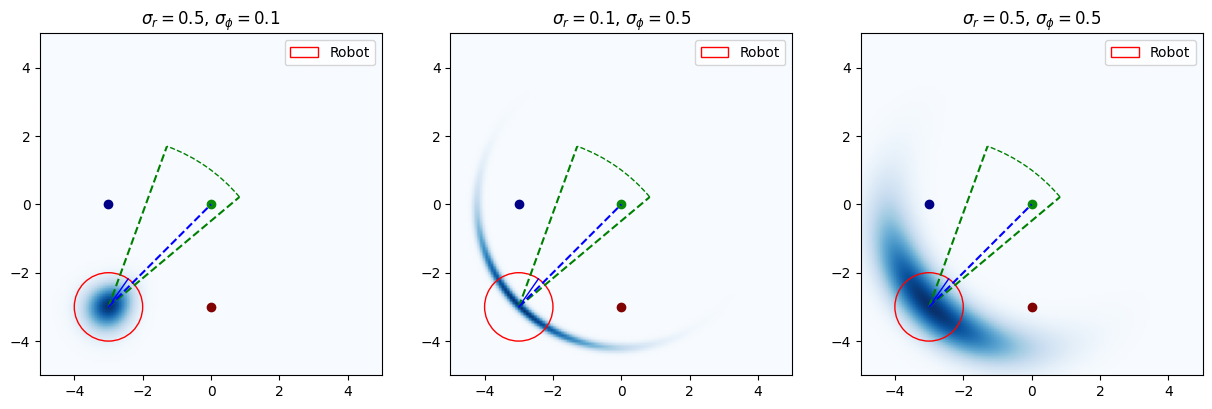

In [7]:
f = plt.figure(figsize=(15,5))

ax1 = plt.subplot(1,3, 1)
ax1.set_title("$\\sigma_r = 0.5$, $\\sigma_{\\phi} = 0.1$")
plotExperiment1(ax1, m, x0, sigma_r= 0.5)

ax2 = plt.subplot(1,3, 2)
ax2.set_title("$\\sigma_r = 0.1$, $\\sigma_{\\phi} = 0.5$")
plotExperiment1(ax2, m, x0, sigma_phi=0.5)

ax3 = plt.subplot(1,3, 3)
ax3.set_title("$\\sigma_r = 0.5$, $\\sigma_{\\phi} = 0.5$")
plotExperiment1(ax3, m, x0, sigma_phi=0.5, sigma_r=0.5)

#### Example 2
In this example we plot the probability distribution for an increasing number of detected landmarks assuming that we know the orientation of the robot at the time of measuremnt. This allows us to reduce/focus the region where the robot is located with high probablilty. In other words, the more landmarks are detected the less ambiguity/possibilities exist for that configuration of position-to-landmarks measurements.

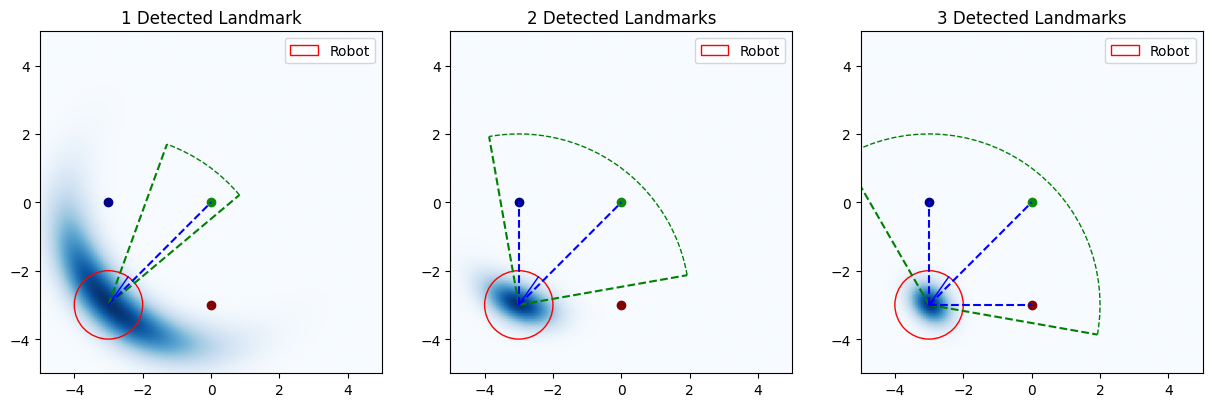

In [8]:
f = plt.figure(figsize=(15,5))

ax1 = plt.subplot(1,3, 1)
ax1.set_title("1 Detected Landmark")
plotExperiment2(ax1, m, x0, fov=Angle.from_deg(30))

ax2 = plt.subplot(1,3, 2)
ax2.set_title("2 Detected Landmarks")
plotExperiment2(ax2, m, x0, fov=Angle.from_deg(90))

ax3 = plt.subplot(1,3, 3)
ax3.set_title("3 Detected Landmarks")
plotExperiment2(ax3, m, x0, fov=Angle.from_deg(130))

#### Experiment 3
If a know orientation can not be assumed, a sweep across the range $\theta_h \in[0:360[$ of possible orientations must be performed, to find likely positions. However, this imples that with a single landmark we cannot infere a single point as possible location for the robot, instead we find that the most likely position is equally likely anywhere on the circle at the measured distance from the landmark. This approach is not only less precise, but also computationally more intense due to the unknown orientation.

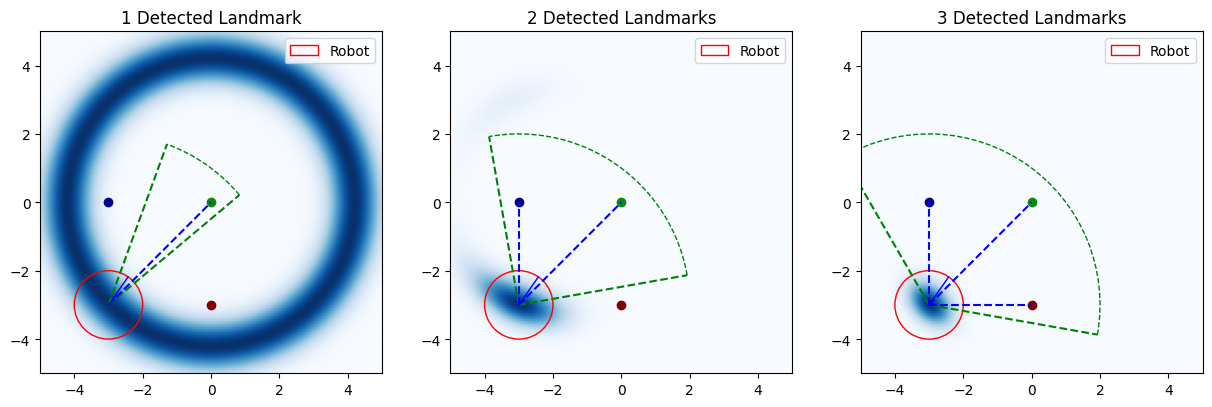

In [9]:
f = plt.figure(figsize=(15,5))

ax1 = plt.subplot(1,3, 1)
ax1.set_title("1 Detected Landmark")
plotExperiment3(ax1, m, x0, fov=Angle.from_deg(30))

ax2 = plt.subplot(1,3, 2)
ax2.set_title("2 Detected Landmarks")
plotExperiment3(ax2, m, x0, fov=Angle.from_deg(90))

ax3 = plt.subplot(1,3, 3)
ax3.set_title("3 Detected Landmarks")
plotExperiment3(ax3, m, x0, fov=Angle.from_deg(130))

### Landmark Localization Sample Distribution
Alternatively to estimate a region of the robots likely position, a distribution of samples can be generated, similarly as we have already seen with the displacement models (Odometry Model and Velocity Model). After generating the samples we can see potential positions of the robot. Regions where the number of samples is higher indicates a higher likelyhood for the robot to be in that region. This can be seen better with a 2D histogramm, plotted in the case of the second experiment, where the highest count is more difficult to spot.

In [7]:
def sample_landmark_model_known_correspondence(feature: DetectedFeature, correspondence: int, map: LandmarkMap, sigmas = [0.1, 0.1]):
    [sigma_r, sigma_phi, sigma_s] = sigmas

    l = map.landmarks[correspondence]
    m_x, m_y = l.pos.x, l.pos.y

    gamma_hat = Angle(np.random.rand() * np.pi * 2)
    r_hat = feature.r + GaussianDistribution(sigma_r**2).sample()
    phi_hat = feature.phi + Angle(GaussianDistribution(sigma_phi**2).sample())

    return Pose(
        m_x + r_hat * gamma_hat.cos,
        m_y + r_hat * gamma_hat.sin,
        gamma_hat - Angle(np.pi) - phi_hat
    )

For the samples, opposed to the probability distrinution, the orientation of the robot is not considered at all. 

In [26]:
def plotLandmarkMeasurmentSampleDistribution(
        ax: plt.Axes, 
        fs: list[DetectedFeature],
        cs: list[int],
        m: LandmarkMap,
        sigmas: tuple[float, float, float] = (0.1, 0.1, 0.1), 
        n_samples: int = 1000, 
        x_interval: list[float, float] = [-5., 5.], 
        y_interval: list[float, float] = [-5., 5.],
    ):

    samples = []

    for f, c in zip(fs, cs):
        for _ in range(n_samples):
            sample = sample_landmark_model_known_correspondence(f, c, m, sigmas)
            samples.append([sample.x, sample.y])
            
            ax.scatter(sample.x, sample.y, color="#184eb321", marker='.')
    
    ax.set_xlim(x_interval[0], x_interval[1])
    ax.set_ylim(y_interval[0], y_interval[1])

    return samples

def plotSampleExperiment1(ax: plt.Axes, m: LandmarkMap, x0: Pose, sigma_r: float = 0.1, sigma_phi: float = 0.1):
    r = Robot(x0)
    c = Camera(Pose(0,0,Angle(0)),robot_pose=r.pos, field_of_veiw=Angle.from_deg(30))
    c.getReading(m,detection_noise=False)

    m.draw(ax)
    r.draw(ax)
    c.draw(ax, draw_sensor_readings=True)

    return plotLandmarkMeasurmentSampleDistribution(ax, c.reading['features'], c.reading['correspondences'], m, sigmas=[sigma_r, sigma_phi, 0.1], x_interval=x_lims, y_interval=y_lims)

def plotSampleExperiment2(ax: plt.Axes, m: LandmarkMap, x0: Pose, fov: Angle, sigmas = [0.2,0.2,0.1]):
    r = Robot(x0)
    c = Camera(Pose(0,0,Angle(0)),robot_pose=r.pos, field_of_veiw=fov)
    c.getReading(m,detection_noise=False)

    m.draw(ax)
    r.draw(ax)
    c.draw(ax, draw_sensor_readings=True)

    return plotLandmarkMeasurmentSampleDistribution(ax, c.reading['features'], c.reading['correspondences'], m, sigmas=sigmas, x_interval=x_lims, y_interval=y_lims)


In [27]:
# plot the 2D histogram of the samples to deduce best position estimate
def round_to_resolution(x: np.ndarray, r: float):
  return np.round(x / r) * r

def plot2Dhist(ax: plt.Axes, samples, resolution = 0.5):
    rounded_samples = round_to_resolution(samples, resolution)

    #create image for 2D histogram
    x_min, x_max = x_lims
    y_min, y_max = y_lims

    nx = int((x_max - x_min) / resolution + 1)
    ny = int((y_max - y_min) / resolution + 1)

    img = np.zeros((ny, nx), dtype=float)

    #compute histogram
    ny, nx = img.shape
    for x in range(nx):
        for y in range(ny):
            xx, yy = x * resolution + x_lims[0], y * resolution + y_lims[0]

            count = np.sum((rounded_samples[:, 0] == xx) & (rounded_samples[:, 1] == yy))
            img[y, x] = count

    #get best estimated position
    best_pos = np.unravel_index(np.argmax(img, axis=None), img.shape)
    best_x = best_pos[1] * resolution + x_lims[0]
    best_y = best_pos[0] * resolution + y_lims[0]

    ax.set_xlim(x_lims)
    ax.set_ylim(y_lims)

    ax.imshow(img / np.max(img), extent=(x_lims[0], x_lims[1], y_lims[0], y_lims[1]), origin='lower', cmap='Blues', alpha=0.5, zorder=0)

    return Pose(best_x, best_y, Angle(0))

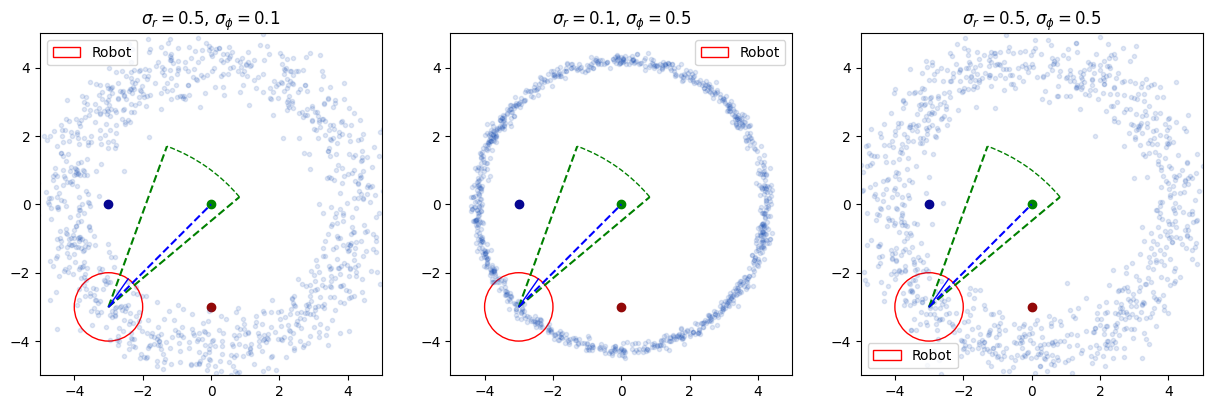

In [28]:
f = plt.figure(figsize=(15,5))

ax1 = plt.subplot(1,3, 1)
ax1.set_title("$\\sigma_r = 0.5$, $\\sigma_{\\phi} = 0.1$")
_ = plotSampleExperiment1(ax1, m, x0, sigma_r= 0.5)

ax2 = plt.subplot(1,3, 2)
ax2.set_title("$\\sigma_r = 0.1$, $\\sigma_{\\phi} = 0.5$")
_= plotSampleExperiment1(ax2, m, x0, sigma_phi=0.5)

ax3 = plt.subplot(1,3, 3)
ax3.set_title("$\\sigma_r = 0.5$, $\\sigma_{\\phi} = 0.5$")
_= plotSampleExperiment1(ax3, m, x0, sigma_phi=0.5, sigma_r=0.5)

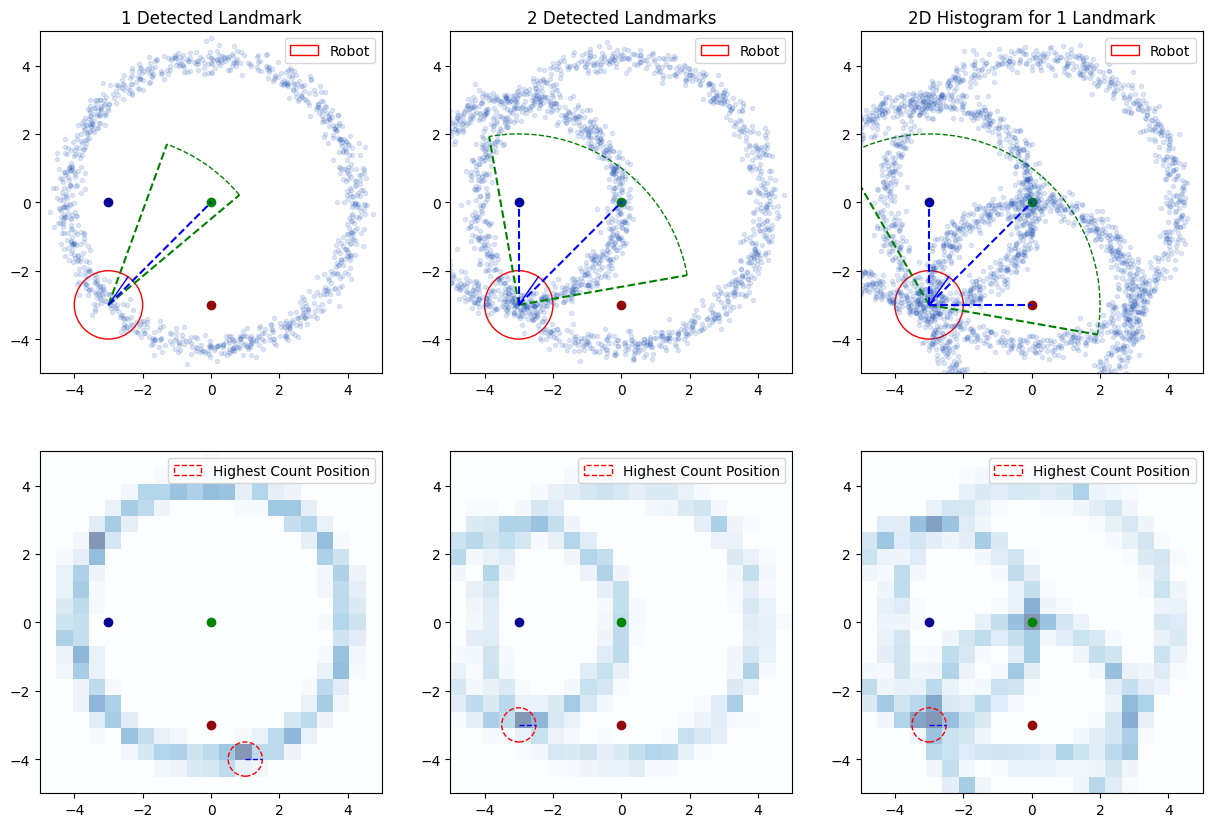

In [ ]:
f = plt.figure(figsize=(15,10))

ax1 = plt.subplot(2,3, 1)
ax1.set_title("1 Detected Landmark")
s1 = plotSampleExperiment2(ax1, m, x0, fov=Angle.from_deg(30))

ax2 = plt.subplot(2,3, 2)
ax2.set_title("2 Detected Landmarks")
s2 = plotSampleExperiment2(ax2, m, x0, fov=Angle.from_deg(90))

ax3 = plt.subplot(2,3, 3)
ax3.set_title("3 Detected Landmarks")
s3 = plotSampleExperiment2(ax3, m, x0, fov=Angle.from_deg(130))

ax4 = plt.subplot(2,3, 4)
ax4.set_title("2D Histogram for 1 Landmark")
m.draw(ax4)
best_pos = plot2Dhist(ax4, samples=np.array(s1))
Robot(best_pos, name="Highest Count Position").draw(ax4, r=0.5, linestyles=['--','--'])

ax5 = plt.subplot(2,3, 5)
ax5.set_title("2D Histogram for 2 Landmarks")
m.draw(ax5)
best_pos = plot2Dhist(ax5, samples=np.array(s2))
Robot(best_pos, name="Highest Count Position").draw(ax5, r=0.5, linestyles=['--','--'])

ax6 = plt.subplot(2,3, 6)
ax6.set_title("2D Histogram for 3 Landmarks")
m.draw(ax6)
best_pos = plot2Dhist(ax6, samples=np.array(s3))
Robot(best_pos, name="Highest Count Position").draw(ax6, r=0.5, linestyles=['--','--'])